MODELE DE RESEAU DE NEURONES CONVOLUTIFS

In [ ]:
"""
Modèle CNN avec Transfer Learning ResNet50  V1


"""

'\nModèle CNN avec Transfer Learning ResNet50\n\n\n'

In [2]:
# Import des librairies principales

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import Input, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Importation pour la transformation des images
# Imports nécessaires pour construire / sauvegarder / évaluer le modèle
# from tensorflow.keras.models import Model
# rom tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    RandomContrast,
    RandomFlip,
    RandomRotation,
    RandomTranslation,
    RandomZoom,
)

In [ ]:
# Chemins d'accès

rep_data = "C:\\Users\\Utilisateur\\Documents\\Projet_MLOps\\Champy_Classifier\\data\\"  # Chemin vers les datasets csv + images raw => processed => split
rep_model = "C:\\Users\\Utilisateur\\Documents\\Projet_MLOps\\Champy_Classifier\\models\\"  # Chemin vers les sauvegardes modèle

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    rep_data + "split\\train", image_size=(224, 224), batch_size=64, shuffle=True, seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    rep_data + "split\\val", image_size=(224, 224), batch_size=64, shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    rep_data + "split\\test", image_size=(224, 224), batch_size=64, shuffle=False
)

Found 18016 files belonging to 30 classes.
Found 3842 files belonging to 30 classes.
Found 3992 files belonging to 30 classes.


In [6]:
class_names = train_ds.class_names
class_names

['Agaricus bisporus',
 'Agaricus campestris',
 'Amanita muscaria',
 'Amanita phalloides',
 'Amanita rubescens',
 'Armillaria mellea',
 'Auricularia auricula-judae',
 'Boletus edulis',
 'Cantharellus cibarius',
 'Clitocybe nebularis',
 'Coprinus comatus',
 'Craterellus cornucopioides',
 'Craterellus lutescens',
 'Ganoderma applanatum',
 'Hydnum repandum',
 'Lactarius deliciosus',
 'Macrolepiota procera',
 'Marasmius oreades',
 'Phallus impudicus',
 'Pleurotus ostreatus',
 'Russula cyanoxantha',
 'Russula emetica',
 'Russula olivacea',
 'Russula rosea',
 'Russula sanguinea',
 'Russula vesca',
 'Russula virescens',
 'Schizophyllum commune',
 'Scleroderma citrinum',
 'Trametes versicolor']

In [7]:
# Définition des couches de transformation
random_translation = RandomTranslation(0.1, 0.1)  # Étirement
random_zoom = RandomZoom(0.1)  # Agrandissement
random_flip = RandomFlip("horizontal")  # Retournement horizontal
random_rotation = RandomRotation(0.1)  # Rotation
random_contrast = RandomContrast(0.1)  # Contraste

In [8]:
# Création du pipe

NUM_CLASSES = 30

inputs = Input(shape=(224, 224, 3))

# Data augmentation
x = random_translation(inputs)
x = random_zoom(x)
x = random_flip(x)
x = random_rotation(x)
x = random_contrast(x)

# Préprocess ResNet50 (à la place du Rescaling)
x = preprocess_input(x)

# Backbone ResNet50
base_model = ResNet50(
    include_top=False,  # on enlève la couche de classification ImageNet
    weights="imagenet",
    input_tensor=x,
)

base_model.trainable = False  # phase 1 : on gèle

# Tête de classification
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model_resnet = Model(inputs, outputs)

In [ ]:
# Callback pour sauvegarder le modèle


save = tf.keras.callbacks.ModelCheckpoint(
    rep_model + "cnn_tl_model.keras", monitor="val_loss", mode="min", save_best_only=True
)


# Callback pour réduire le taux d'apprentissage
reduceLR = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    patience=3,
    factor=0.5,
    min_delta=0.001,
    cooldown=1,
    min_lr=1e-6,
    verbose=1,
)

# Callback pour stopper l'apprentissage quand il ne progresse plus
early_stop = EarlyStopping(
    patience=6,  # Nombre d'époques sans amélioration avant arrêt
    min_delta=0.001,
    mode="min",
    monitor="val_loss",  # On surveille la perte sur l'ensemble de validation
    restore_best_weights=True,
)

In [10]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [11]:
history_model1 = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # 15 voire 20
    callbacks=[reduceLR, save, early_stop],
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 241s 845ms/step - accuracy: 0.3889 - loss: 2.2285 - val_accuracy: 0.5781 - val_loss: 1.4362 - learning_rate: 0.0010
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 234s 830ms/step - accuracy: 0.6659 - loss: 1.1103 - val_accuracy: 0.6192 - val_loss: 1.3712 - learning_rate: 0.0010
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 233s 828ms/step - accuracy: 0.7349 - loss: 0.8739 - val_accuracy: 0.6098 - val_loss: 1.4388 - learning_rate: 0.0010
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 234s 832ms/step - accuracy: 0.7631 - loss: 0.7670 - val_accuracy: 0.6200 - val_loss: 1.4164 - learning_rate: 0.0010
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.7963 - loss: 0.6643
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
282/282 ━━━━━━━━━━━━━━━━━━━━ 236s 838ms/step - accuracy: 0.7963 - loss: 0.6642 - val_accuracy: 0.6088 - val_loss: 1.5440 - learning_rate: 0.0010
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 234s 829ms/step - accuracy:

In [12]:
# Dégèle
base_model.trainable = True


fine_tune_at = 140  # ResNet50 a environ 175 couches
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


"""
# Pour dégeler la totalité :
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
"""

'\n# Pour dégeler la totalité :\nfor layer in base_model.layers:\n    if isinstance(layer, layers.BatchNormalization):\n        layer.trainable = False\n'

In [13]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [14]:
history_model2 = model_resnet.fit(
    train_ds, validation_data=val_ds, epochs=40, callbacks=[reduceLR, save, early_stop]
)

Epoch 1/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.6775 - loss: 1.1103 - val_accuracy: 0.6525 - val_loss: 1.2224 - learning_rate: 1.0000e-05
Epoch 2/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.7943 - loss: 0.7015 - val_accuracy: 0.6661 - val_loss: 1.2119 - learning_rate: 1.0000e-05
Epoch 3/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.8238 - loss: 0.5731 - val_accuracy: 0.6718 - val_loss: 1.2152 - learning_rate: 1.0000e-05
Epoch 4/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.8542 - loss: 0.4926 - val_accuracy: 0.6736 - val_loss: 1.2307 - learning_rate: 1.0000e-05
Epoch 5/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.8698 - loss: 0.4186 - val_accuracy: 0.6793 - val_loss: 1.2093 - learning_rate: 1.0000e-05
Epoch 6/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.8918 - loss: 0.3657 - val_accuracy: 0.6819 - val_loss: 1.2152 - learning_rate: 1.0000e-05
Epoch 7/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - acc

In [ ]:
np.save(rep_model + "cnn_tl_model_history.npy", history_model2.history)

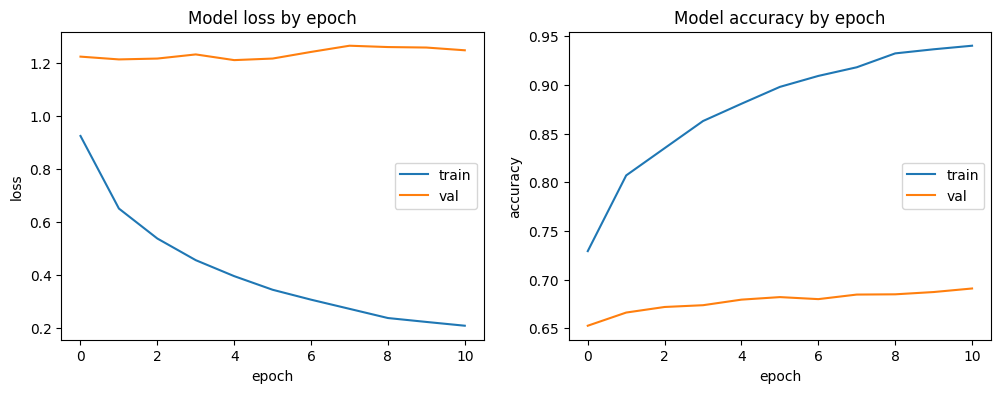

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(history_model2.history["loss"])
plt.plot(history_model2.history["val_loss"])
plt.title("Model loss by epoch")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="right")

plt.subplot(122)
plt.plot(history_model2.history["accuracy"])
plt.plot(history_model2.history["val_accuracy"])
plt.title("Model accuracy by epoch")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="right")
plt.show()

In [17]:
# Fonction pour obtenir les prédictions


def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        preds = model_resnet.predict(images, verbose=0)
        pred_labels.extend(np.argmax(preds, axis=-1))

        true_labels.extend(labels.numpy())

    return np.array(true_labels), np.array(pred_labels)


y_true, y_pred = get_predictions_and_labels(test_ds)  # test, pas val

# Afficher le rapport de classification
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.55      0.65       119
           1       0.58      0.67      0.62       126
           2       0.66      0.81      0.73       135
           3       0.47      0.84      0.60       135
           4       0.48      0.40      0.44       130
           5       0.60      0.66      0.63       125
           6       0.74      0.73      0.74       147
           7       0.52      0.92      0.66       136
           8       0.90      0.88      0.89       131
           9       0.78      0.59      0.67       132
          10       0.66      0.90      0.76       135
          11       0.83      0.71      0.77       142
          12       0.91      0.65      0.76       142
          13       0.64      0.91      0.75       135
          14       0.68      0.67      0.67       126
          15       0.75      0.71      0.73       116
          16       0.60      0.76      0.67       124
          17       0.88    

Text(0.5, 135.7222222222222, 'Labels prédits')

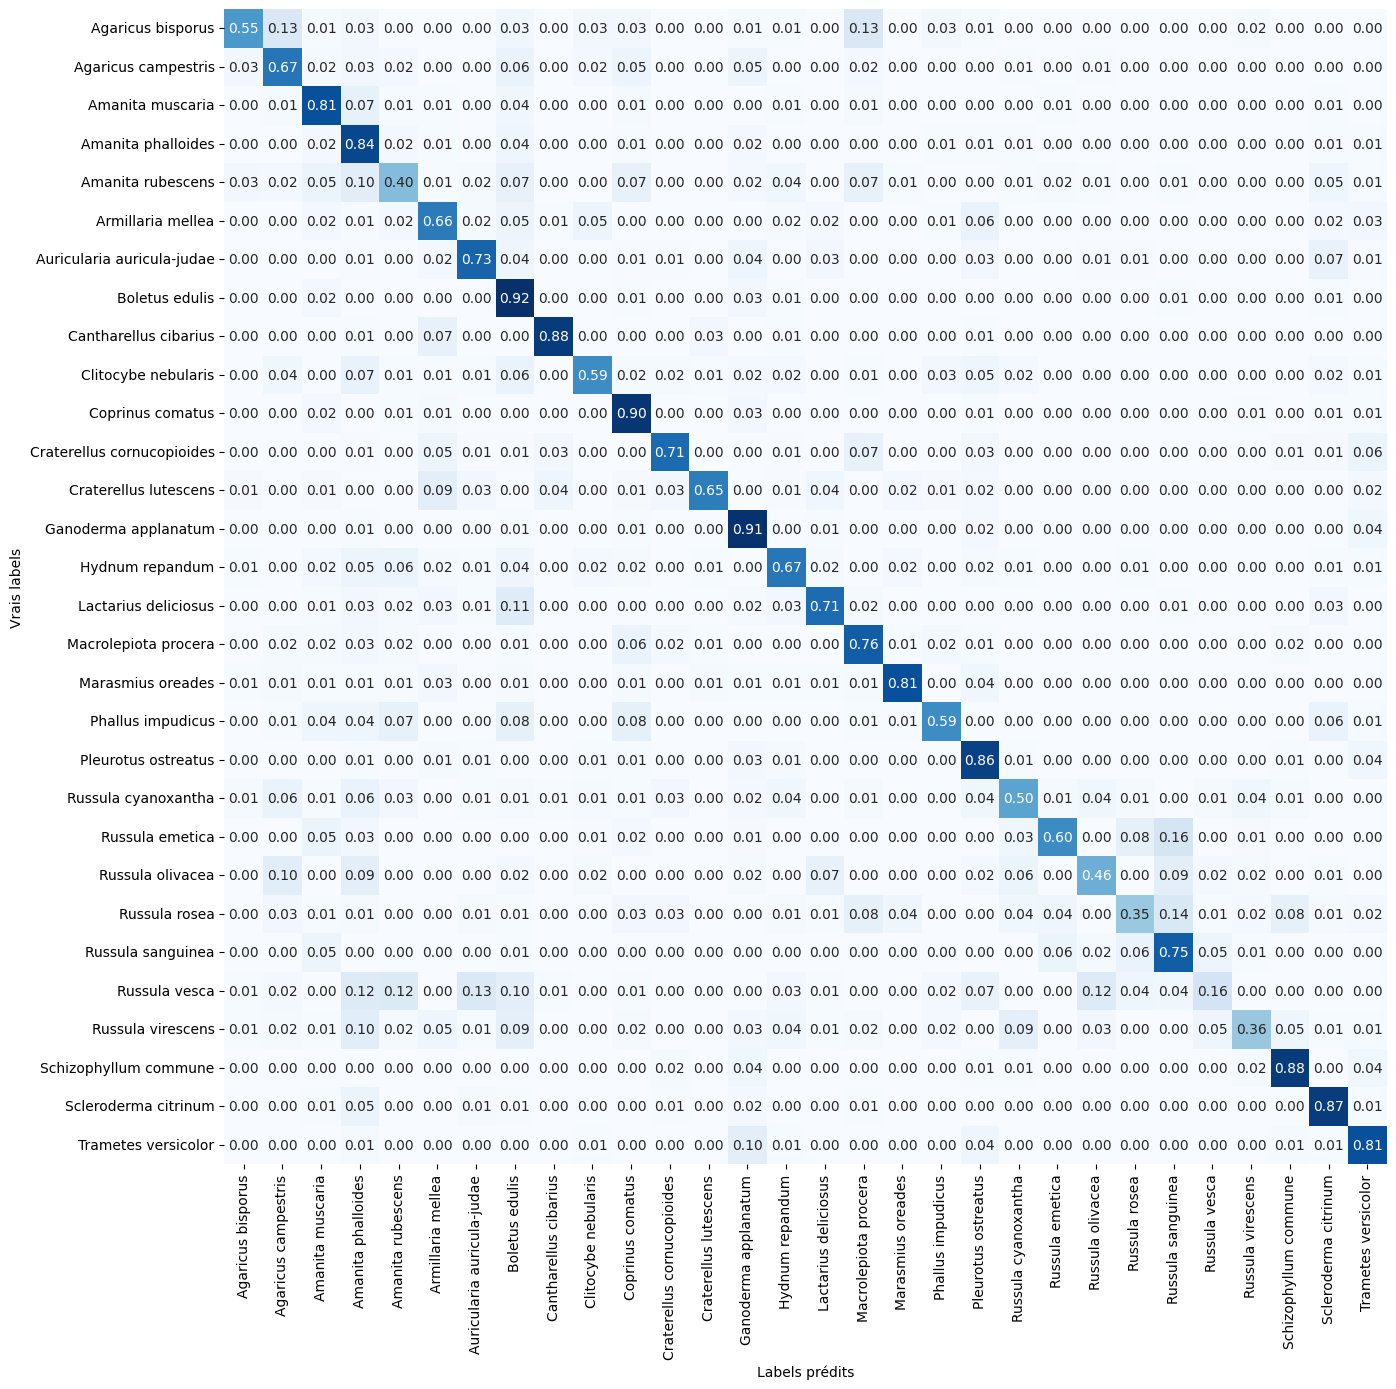

In [18]:
# Affichage de la matrice de confusion "Rappel" (normalisée par ligne, normalize = 'true')
plt.figure(figsize=(15, 15))
cnf_matrix = confusion_matrix(y_true, y_pred, normalize="true")
ax = sns.heatmap(cnf_matrix, cmap="Blues", annot=True, cbar=False, fmt=".2f")
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names, rotation=0)
plt.ylabel("Vrais labels")
plt.xlabel("Labels prédits")

Text(0.5, 135.7222222222222, 'Labels prédits')

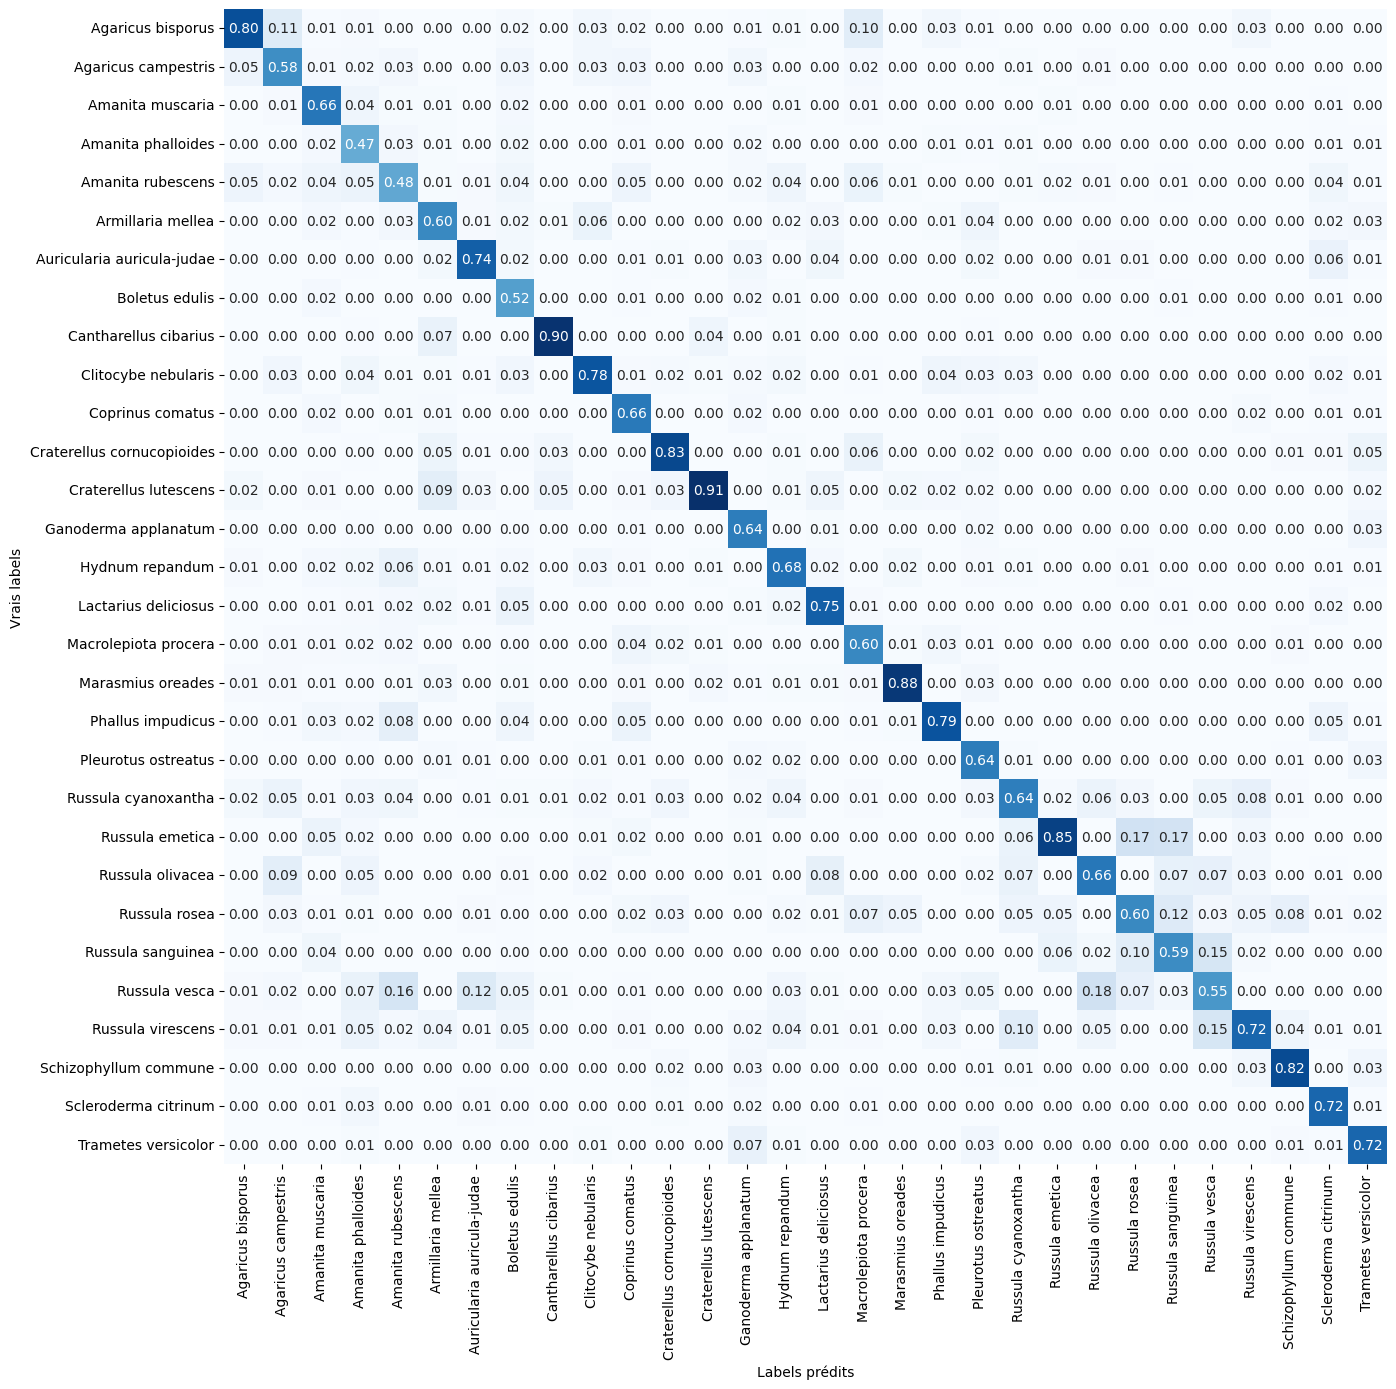

In [19]:
# Affichage de la matrice de confusion "Précision" (normalisée par colonne, normalize = 'pred')
plt.figure(figsize=(15, 15))
cnf_matrix = confusion_matrix(y_true, y_pred, normalize="pred")
ax = sns.heatmap(cnf_matrix, cmap="Blues", annot=True, cbar=False, fmt=".2f")
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names, rotation=0)
plt.ylabel("Vrais labels")
plt.xlabel("Labels prédits")